# l–b and l–v maps

Longitude–latitude and longitude–velocity diagrams for CO-weighted gas.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Repo root on sys.path so `import simviz` works without install
sys.path.insert(0, str(Path("..").resolve()))

EXAMPLE_OUT = Path("../example_output")
EXAMPLE_OUT.mkdir(exist_ok=True)

# Pickle path for transformed arrays
CACHE_FILE = EXAMPLE_OUT / ".lbv_cache.npz"

from simviz.utils import read_snapshot_hdf5, calc_co_quantities, CONSTANTS
from simviz.projections import rotate_to_bar_frame, rotate_xy, xyz_to_lbr
from simviz.field_plots import create_lbrv_maps, plot_lb_lv

Set `snap_path` then run the cells below.


In [2]:
# Snapshot HDF5
snap_path = Path("../sample_snaps/phoenix_stinks_1Msun_999.hdf5")

data, header = read_snapshot_hdf5(snap_path)

t   = float(header["Time"])
box = float(header["BoxSize"])
print(f"t = {t:.4f} code  ({t * 98.7:.1f} Myr)   BoxSize = {box}")
print(f"N gas cells: {len(data['Masses']):,}")

t = 2.4519 code  (242.0 Myr)   BoxSize = 1000.0
N gas cells: 88,964,811


CO mass per cell from chemical abundances; used as histogram weights.


In [3]:
masses_co, co_colden_cm = calc_co_quantities(
    data["Density"], data["Masses"], data["ChemicalAbundances"]
)
print(f"Total CO mass: {masses_co.sum():.3e} Msun (code units)")

Total CO mass: 3.784e+05 Msun (code units)


GC centre, bar frame, galactic (l,b,vr), CMZ longitude cut, then rotate so the Sun sits at (x,y)=(0,-8 kpc).


In [4]:
x, y, z   = np.array(data["Coordinates"]).T
vx, vy, vz = np.array(data["Velocities"]).T

# Centre on GC
x -= box / 2
y -= box / 2
z -= box / 2

# Bar frame
x, y, vx, vy = rotate_to_bar_frame(x, y, vx, vy, t)

# Galactic l, b (rad); v_r km/s
l, b, r, vl, vb, vr = xyz_to_lbr(x, y, z, vx, vy, vz)
l_deg = np.degrees(l)
b_deg = np.degrees(b)

# CMZ cut |l| < 6°
l_cut_deg = 6.0
mask = np.abs(l_deg) < l_cut_deg
print(f"Cells inside |l| < {l_cut_deg}°: {mask.sum():,} / {len(mask):,}")

x, y, vx, vy         = x[mask], y[mask], vx[mask], vy[mask]
l_deg, b_deg, r, vr  = l_deg[mask], b_deg[mask], r[mask], vr[mask]
masses_co            = masses_co[mask]

# Sun at (x,y)=(0,-8 kpc)
x, y   = rotate_xy(x, y,   np.pi / 2)
vx, vy = rotate_xy(vx, vy, np.pi / 2)

Cells inside |l| < 6.0°: 73,484,302 / 88,964,811


Coordinate transform is slow, so use these cells to save, then load for later runs.


In [5]:
# Write cache (after sections 1–3)
np.savez(CACHE_FILE, l_deg=l_deg, b_deg=b_deg, r=r, vr=vr, masses_co=masses_co, t=np.array(t))
print("Saved →", CACHE_FILE)

Saved → ../example_output/.lbv_cache.npz


In [2]:
# Read cache (skips sections 1–3)
_d = np.load(CACHE_FILE)
l_deg, b_deg, r, vr, masses_co = _d["l_deg"], _d["b_deg"], _d["r"], _d["vr"], _d["masses_co"]
t = float(_d["t"])
print("Loaded ←", CACHE_FILE)

Loaded ← ../example_output/.lbv_cache.npz


Histogram CO mass into l–b and l–v. Default grid: ±2.3° in l, ±1.5° in b; override with `grid=`.


In [3]:
lb_map, lv_map, ls, bs, vs = create_lbrv_maps(l_deg, b_deg, vr, r, masses_co)
print(f"l–b map shape: {lb_map.shape}   l–v map shape: {lv_map.shape}")

l–b map shape: (3002, 4602)   l–v map shape: (414, 4602)


`vmin` / `vmax`: colour stretch. Pass `axes=` to embed in another figure.


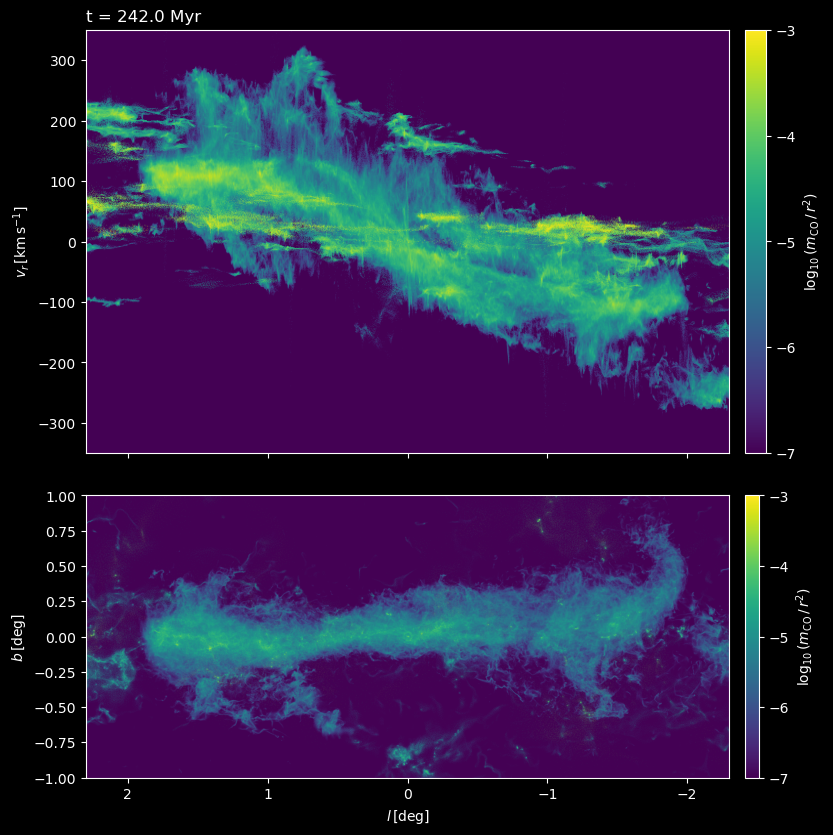

In [4]:
plt.style.use("dark_background")

fig, axes = plot_lb_lv(lb_map, lv_map, ls, bs, vs, vmin=1e-7, vmax=1e-3)

ax_lv, ax_lb = axes
ax_lv.set_title(f"t = {t * 98.7:.1f} Myr", loc="left")
fig.savefig(EXAMPLE_OUT / "lbv_main.png", dpi=180, bbox_inches="tight")

plt.show()

Narrower l–b window for the dense ring.


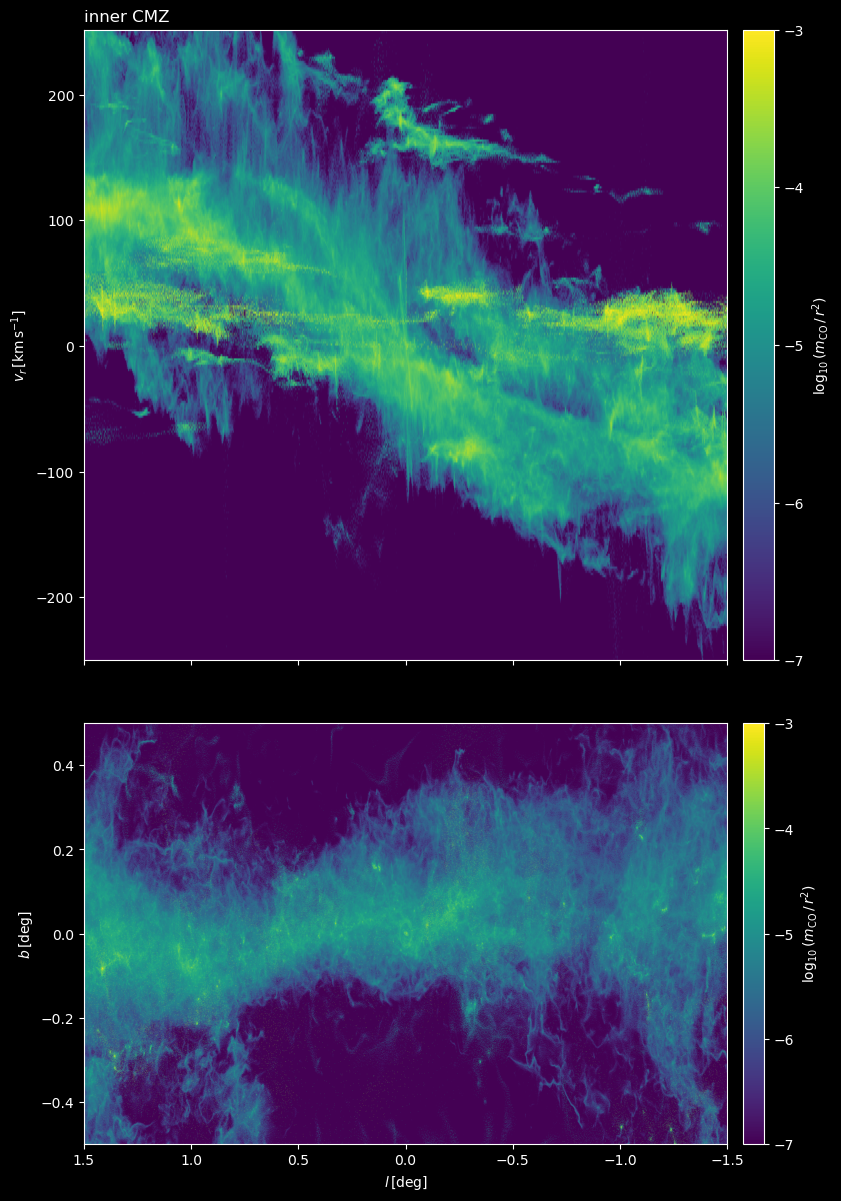

In [5]:
# Inner CMZ grid example
custom_grid = {
    "lmin": -1.5, "lmax": 1.5,
    "bmin": -0.5, "bmax": 0.5,
    "vmin": -250.0, "vmax": 250.0,
}

lb_zoom, lv_zoom, ls_z, bs_z, vs_z = create_lbrv_maps(
    l_deg, b_deg, vr, r, masses_co, grid=custom_grid
)

fig2, axes2 = plot_lb_lv(lb_zoom, lv_zoom, ls_z, bs_z, vs_z, vmin=1e-7, vmax=1e-3)
axes2[0].set_title("inner CMZ", loc="left")
fig2.savefig(EXAMPLE_OUT / "lbv_inner_cmz.png", dpi=180, bbox_inches="tight")
plt.show()